#**В биоинформатике и биомедицине понимание структуры данных — это 80% успеха, так как ошибки на этом этапе делают даже самую сложную модель бесполезной.**

Для начала об объектах, признаках и целевой переменной

In [1]:
# @title
import pandas as pd

data = {
    'ID_пациента': ['P-01', 'P-02', 'P-03', 'P-04', 'P-05'],
    'Возраст': [45, 52, 38, 61, 29],
    'Уровень_глюкозы': [110, 155, 98, 185, 102],
    'Экспрессия_гена_X': [1.2, 0.7, 1.1, 0.4, 1.0],
    'Заболевание (Target)': [0, 1, 0, 1, 0],
}
df = pd.DataFrame(data)

# --- Тёмная палитра ---
BG_BASE   = '#1e1e1e'; FG_BASE   = '#e0e0e0'
BG_TARGET = '#4a1f1f'; FG_TARGET = '#ffb3b3'   # красный  -> Target
BG_FEAT   = '#1a3a5c'; FG_FEAT   = '#cce5ff'   # синий    -> Feature
BG_INST   = '#5c4a1a'; FG_INST   = '#ffe9a8'   # жёлтый   -> Instance
BORDER    = '#444444'

def hl_target(s):
    return [f'background-color:{BG_TARGET};color:{FG_TARGET};font-weight:bold'] * len(s)

def hl_feature(s):
    return [f'background-color:{BG_FEAT};color:{FG_FEAT}'] * len(s)

def hl_instance(s):
    if s.name == 2:                      # строка P-03
        return [f'background-color:{BG_INST};color:{FG_INST};font-weight:bold'] * len(s)
    return [''] * len(s)

styled_df = (
    df.style
      .set_properties(**{'background-color': BG_BASE, 'color': FG_BASE})
      .apply(hl_target,    subset=['Заболевание (Target)'])
      .apply(hl_feature,   subset=['Уровень_глюкозы'])
      .apply(hl_instance,  subset=pd.IndexSlice[2, ['ID_пациента', 'Возраст', 'Экспрессия_гена_X']], axis=1)
      .set_table_styles([
          {'selector': 'table',   'props': [('border-collapse', 'collapse')]},
          {'selector': 'th',      'props': [('background-color', '#2d2d2d'),
                                            ('color', '#e0e0e0'),
                                            ('border', f'1px solid {BORDER}'),
                                            ('padding', '6px 10px')]},
          {'selector': 'td',      'props': [('border', f'1px solid {BORDER}'),
                                            ('padding', '6px 10px')]},
          {'selector': 'caption', 'props': [('color', '#e0e0e0'),
                                            ('font-size', '14px'),
                                            ('caption-side', 'bottom'),
                                            ('padding-top', '8px')]},
      ])
      .set_caption(
          "🔬 Биомедицинский датасет<br>"
          "🟨 Жёлтый — объект (строка, Instance/Sample)<br>"
          "🟦 Синий — признак (столбец, Feature)<br>"
          "🟥 Красный — целевая переменная (Target)"
      )
)

styled_df

,ID_пациента,Возраст,Уровень_глюкозы,Экспрессия_гена_X,Заболевание (Target)
0,P-01,45,110,1.200000,0
1,P-02,52,155,0.700000,1
2,P-03,38,98,1.100000,0
3,P-04,61,185,0.400000,1
4,P-05,29,102,1.000000,0


Объект — это одна строка таблицы. Один конкретный случай, который описывается целиком.

Признак — это одна колонка (кроме целевой). Одно измеримое свойство объекта.

Целевая переменная — это та колонка, которую модель должна научиться предсказывать. Это «ответ», «исход», «то, ради чего всё затевается».



#Однако далеко не всегда объекты, признаки и переменные очевидны
Смотря на данные вы должны понимать, где здесь объект, где описания этого объекта и что будем предсказывать, какая целевая переменная для анализа

Задача 1: ген - экспрессия

Объект (Instance): Что здесь объект?
❓ Признаки (Features): Что мы знаем о каждом гене?
❓ Target: Что предсказываем?

In [2]:
import pandas as pd

gene_data = {
    'Символ_гена': ['TP53', 'BRCA1', 'EGFR', 'MYC', 'VEGFA'],
    'Экспрессия_в_образце_1': [5.2, 1.1, 8.3, 3.4, 6.7],  # Экспрессия_в_образце_1
    'Экспрессия_в_образце_2': [4.8, 0.9, 9.1, 3.8, 7.2],  # Экспрессия_в_образце_2
    'Экспрессия_в_образце_3': [5.5, 1.3, 7.9, 3.1, 6.1],  # Экспрессия_в_образце_3
    'Является_онкогеном': [1, 1, 0, 1, 0]  #онкоген_или_нет
}

df_genes = pd.DataFrame(gene_data)
df_genes

,Символ_гена,Экспрессия_в_образце_1,Экспрессия_в_образце_2,Экспрессия_в_образце_3,Является_онкогеном
0,TP53,5.2,4.8,5.5,1
1,BRCA1,1.1,0.9,1.3,1
2,EGFR,8.3,9.1,7.9,0
3,MYC,3.4,3.8,3.1,1
4,VEGFA,6.7,7.2,6.1,0


Задача 2:
Лекарственные молекулы (хемоинформатика)

❓ Объект: Что здесь объект?
❓ Признаки: Что описывает объект?
❓ Target: Что предсказываем?

In [3]:
# Данные о молекулах препаратов
drug_data = {
    'Molecular_Weight': [350.2, 420.5, 280.1, 510.8, 390.4], #молекулярный вес
    'Is_Cardiotoxic': [0, 1, 0, 1, 0], #кардиотоксичность
    'LogP': [2.3, 4.1, 1.8, 5.2, 3.0],  # Липофильность
    'H_Bond_Donors': [2, 1, 3, 0, 2], #водородные связи 1
    'Drug_ID': ['D001', 'D002', 'D003', 'D004', 'D005'], #ID лекарства
    'H_Bond_Acceptors': [5, 7, 4, 9, 6] #водородные связи 2
}

df_drugs = pd.DataFrame(drug_data)
df_drugs

,Molecular_Weight,Is_Cardiotoxic,LogP,H_Bond_Donors,Drug_ID,H_Bond_Acceptors
0,350.2,0,2.3,2,D001,5
1,420.5,1,4.1,1,D002,7
2,280.1,0,1.8,3,D003,4
3,510.8,1,5.2,0,D004,9
4,390.4,0,3.0,2,D005,6


Задача 3: RNA-seq, вам принесли проанализированные образцы биопсии

❓ Объект: Что здесь строка?

❓ Признаки: Что является features?

❓ Target: Что предсказываем?


In [4]:
import pandas as pd
import numpy as np


rna_seq_data = {
    'Sample_ID': ['T001', 'T002', 'T003', 'T004', 'T005', 'T006'], #ID ткани
    'Patient_ID': ['P01', 'P02', 'P01', 'P03', 'P04', 'P05'], #ID пациента
    'Tissue_Type': ['Tumor', 'Normal', 'Tumor', 'Tumor', 'Normal', 'Tumor'], #что за ткань
    'Gene_TP53_logCPM': [8.2, 6.1, 7.9, 3.4, 6.5, 2.8],  # Логарифмированная экспрессия (CPM)
    'Gene_BRCA1_logCPM': [5.1, 5.8, 4.9, 2.1, 6.2, 1.9],
    'Gene_EGFR_logCPM': [9.3, 4.2, 10.1, 11.2, 3.8, 12.5],
    'Gene_MYC_logCPM': [7.6, 5.4, 8.1, 9.8, 4.9, 10.2],
    'Reads': [45.2, 42.1, 48.5, 39.8, 44.3, 41.2],  # Качество секвенирования
    'Tumor_Stage': ['II', 'NA', 'III', 'IV', 'NA', 'III'],  # Стадия рака
    'Is_High_Grade': [1, 0, 1, 1, 0, 1]  #высокая степень злокачественности
}

df_rna = pd.DataFrame(rna_seq_data)
df_rna

,Sample_ID,Patient_ID,Tissue_Type,Gene_TP53_logCPM,Gene_BRCA1_logCPM,Gene_EGFR_logCPM,Gene_MYC_logCPM,Reads,Tumor_Stage,Is_High_Grade
0,T001,P01,Tumor,8.2,5.1,9.3,7.6,45.2,II,1
1,T002,P02,Normal,6.1,5.8,4.2,5.4,42.1,NA,0
2,T003,P01,Tumor,7.9,4.9,10.1,8.1,48.5,III,1
3,T004,P03,Tumor,3.4,2.1,11.2,9.8,39.8,IV,1
4,T005,P04,Normal,6.5,6.2,3.8,4.9,44.3,NA,0
5,T006,P05,Tumor,2.8,1.9,12.5,10.2,41.2,III,1


#Переходим к типам признаков
«Признак» — это роль, а не тип данных. Одна и та же колонка может быть признаком (входом) в одной задаче и целевой переменной в другой.

А вот тип признака определяется тем, какие значения он принимает и что с ними можно делать. От типа напрямую зависит, как с признаком обращаться: можно ли считать среднее, можно ли сравнивать значения по порядку, нужно ли кодировать в числа.


📊 ЧИСЛОВЫЕ ПРИЗНАКИ (Numerical Features)

1. Непрерывные (Continuous)

In [5]:
import pandas as pd
import numpy as np

continuous_features = {
    'Patient_ID': ['P001', 'P002', 'P003', 'P004', 'P005'],

    # НЕПРЕРЫВНЫЕ признаки (могут быть дробными):
    'Blood_Pressure_Systolic': [120.5, 135.2, 118.7, 142.3, 125.8],  # мм рт.ст.
    'Cholesterol_Total': [5.2, 6.8, 4.9, 7.1, 5.5],  # ммоль/л
    'Body_Temperature': [36.6, 37.2, 36.9, 38.1, 37.0],  # °C
    'Gene_Expression_LogCPM': [8.234, 6.891, 9.456, 7.123, 8.789],  # логарифмированная экспрессия
    'Protein_Concentration': [125.3, 98.7, 145.2, 112.8, 102.4],  # мкг/мл
    'Fold_Enrichment_ChIP': [12.5, 8.3, 15.2, 6.7, 10.1],  # обогащение сигнала
    'GC_Content': [0.42, 0.38, 0.51, 0.45, 0.39],  # доля (0-1)
    'P_value': [0.001, 0.012, 0.0003, 0.045, 0.008],  # статистическая значимость
    'Retention_Time_HPLC': [12.534, 8.321, 15.267, 6.789, 10.145],  # минуты
    'm_z_Ratio': [180.0634, 150.0523, 90.0321, 60.0214, 120.0456]  # масс-спектрометрия
}

df_continuous = pd.DataFrame(continuous_features)
df_continuous

,Patient_ID,Blood_Pressure_Systolic,Cholesterol_Total,Body_Temperature,Gene_Expression_LogCPM,Protein_Concentration,Fold_Enrichment_ChIP,GC_Content,P_value,Retention_Time_HPLC,m_z_Ratio
0,P001,120.5,5.2,36.6,8.234,125.3,12.5,0.42,0.0010,12.534,180.0634
1,P002,135.2,6.8,37.2,6.891,98.7,8.3,0.38,0.0120,8.321,150.0523
2,P003,118.7,4.9,36.9,9.456,145.2,15.2,0.51,0.0003,15.267,90.0321
3,P004,142.3,7.1,38.1,7.123,112.8,6.7,0.45,0.0450,6.789,60.0214
4,P005,125.8,5.5,37.0,8.789,102.4,10.1,0.39,0.0080,10.145,120.0456


Могут принимать ЛЮБОЕ значение в диапазоне, включая дробные.
Ключевая характеристика: Между 120.5 и 120.6 можно найти 120.55, 120.555 и т.д. — бесконечное число значений.

2. Дискретные (Discrete)

In [6]:
discrete_features = {
    'Patient_ID': ['P001', 'P002', 'P003', 'P004', 'P005'],

    # ДИСКРЕТНЫЕ признаки (только целые числа):
    'Num_Previous_Hospitalizations': [0, 2, 1, 3, 0],  # количество госпитализаций
    'Num_Children': [2, 0, 3, 1, 2],  # количество детей
    'Num_Smoking_Years': [0, 15, 8, 20, 5],  # лет курения
    'Num_Genes_Detected': [12450, 8230, 15670, 9890, 11230],  # количество генов
    'Num_Reads_Millions': [45, 42, 48, 39, 44],  # миллионов прочтений (округлено)
    'Num_SNP_Variants': [234, 189, 312, 156, 278],  # количество SNP
    'Num_Previous_Treatments': [0, 1, 2, 0, 3],  # количество предыдущих терапий
    'Num_Family_Members_Disease': [0, 2, 1, 0, 3],  # членов семьи с заболеванием
    'Num_Tumor_Nodes': [0, 3, 1, 5, 2]  # количество опухолевых узлов
}

df_discrete = pd.DataFrame(discrete_features)
df_discrete

,Patient_ID,Num_Previous_Hospitalizations,Num_Children,Num_Smoking_Years,Num_Genes_Detected,Num_Reads_Millions,Num_SNP_Variants,Num_Previous_Treatments,Num_Family_Members_Disease,Num_Tumor_Nodes
0,P001,0,2,0,12450,45,234,0,0,0
1,P002,2,0,15,8230,42,189,1,2,3
2,P003,1,3,8,15670,48,312,2,1,1
3,P004,3,1,20,9890,39,156,0,0,5
4,P005,0,2,5,11230,44,278,3,3,2


Ключевая характеристика: Между 2 и 3 нет промежуточных целых значений. Нельзя иметь 2.5 госпитализации!



ВАЖНОЕ ЗАМЕЧАНИЕ: Не все целые числа — дискретные! Правило: Смотрите на природу явления, а не на формат записи!

Как быстро определить?

-Может ли значение быть дробным в принципе? Если да — непрерывный. Если между двумя соседними значениями нет ничего осмысленного — дискретный.

-Что означает число: количество или измерение? Количество (штук, раз, дней) — дискретный. Измерение (масса, концентрация, температура) — непрерывный.



Задача: определите тип каждого признака: continuous или discrete

In [7]:
# Определите тип каждого признака: continuous или discrete

mixed_features = {
    'ID_пациента': ['P001', 'P002', 'P003'],
    'Индекс_массы_тела': [24.5, 28.3, 22.1],  # ???
    'Кол_во_лекарств_принимаемых': [2, 5, 1],  # ???
    'Креатинин_сыворотки': [1.2, 0.9, 1.4],  # ???
    'Кол_во_дней_госпитализации': [5, 12, 3],  # ???
    'Гемоглобин_г_дл': [14.2, 12.8, 15.1],  # ???
    'Кол_во_аллергий': [0, 2, 1],  # ???
    'pH_крови': [7.4, 7.35, 7.42],  # ???
    'Частота_сердечных_сокращений_в_минуту':      [72, 85, 68], #???
}

df_mixed = pd.DataFrame(mixed_features)
df_mixed

,ID_пациента,Индекс_массы_тела,Кол_во_лекарств_принимаемых,Креатинин_сыворотки,Кол_во_дней_госпитализации,Гемоглобин_г_дл,Кол_во_аллергий,pH_крови,Частота_сердечных_сокращений_в_минуту
0,P001,24.5,2,1.2,5,14.2,0,7.40,72
1,P002,28.3,5,0.9,12,12.8,2,7.35,85
2,P003,22.1,1,1.4,3,15.1,1,7.42,68


Признак дискретен, если между двумя соседними значениями в принципе не может быть промежуточного. Признак непрерывен, если может — даже если на практике мы его округляем.

#🏷️ КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ (Categorical Features)

Описывают принадлежность объекта к определённой группе/категории.

🔹 Номинальные (Nominal)
Группы НЕ имеют естественного порядка. Нельзя сказать, что одна категория "больше" или "лучше" другой, т.е нельзя сравнивать между собой.

In [8]:
import pandas as pd
import numpy as np

# НОМИНАЛЬНЫЕ признаки - порядок НЕ имеет смысла
nominal_features = {
    'Patient_ID': ['P001', 'P002', 'P003', 'P004', 'P005'],

    # Пол - нельзя сказать, что "мужской > женский"
    'Sex': ['Male', 'Female', 'Female', 'Male', 'Female'],

    # Группа крови - нет порядка между A, B, AB, O
    'Blood_Group': ['A', 'B', 'O', 'AB', 'A'],

    # Тип ткани - категории равноправны
    'Tissue_Type': ['Liver', 'Lung', 'Breast', 'Brain', 'Kidney'],

    # Тип мутации - просто разные категории
    'Mutation_Type': ['SNP', 'Insertion', 'Deletion', 'SNP', 'LoF'],

    # Этническая принадлежность
    'Ethnicity': ['Caucasian', 'Asian', 'African', 'Hispanic', 'Caucasian'],
}

df_nominal = pd.DataFrame(nominal_features)
df_nominal

,Patient_ID,Sex,Blood_Group,Tissue_Type,Mutation_Type,Ethnicity
0,P001,Male,A,Liver,SNP,Caucasian
1,P002,Female,B,Lung,Insertion,Asian
2,P003,Female,O,Breast,Deletion,African
3,P004,Male,AB,Brain,SNP,Hispanic
4,P005,Female,A,Kidney,LoF,Caucasian


🔸 Порядковые (Ordinal)
Группы ИМЕЮТ естественный порядок. Можно ранжировать: "меньше → больше", "хуже → лучше".

In [9]:
# ПОРЯДКОВЫЕ признаки - порядок ИМЕЕТ смысл
ordinal_features = {
    'Patient_ID': ['P001', 'P002', 'P003', 'P004', 'P005'],

    # Стадия опухоли - чёткая иерархия: I < II < III < IV
    'Tumor_Stage': ['I', 'III', 'II', 'IV', 'I'],

    # Степень злокачественности (Grade)
    'Tumor_Grade': ['G1', 'G3', 'G2', 'G3', 'G1'],  # G1=низкая, G3=высокая

    # Ответ на терапию - есть порядок
    'Therapy_Response': ['Complete', 'No_Response', 'Partial', 'Progressive', 'Complete'],
    # Нет ответа < Частичный < Полный

    # Стадия хронической болезни почек (CKD)
    'CKD_Stage': ['Stage_2', 'Stage_4', 'Stage_1', 'Stage_5', 'Stage_3'],

    # Степень тяжести состояния пациента
    'Severity': ['Mild', 'Severe', 'Moderate', 'Critical', 'Mild'],

    # Уровень экспрессии (категоризованный)
    'Expression_Level': ['Low', 'High', 'Medium', 'High', 'Low'],

    # Качество образца (RIN score категориями)
    'RNA_Quality': ['Good', 'Poor', 'Excellent', 'Fair', 'Good']
}

df_ordinal = pd.DataFrame(ordinal_features)
df_ordinal

,Patient_ID,Tumor_Stage,Tumor_Grade,Therapy_Response,CKD_Stage,Severity,Expression_Level,RNA_Quality
0,P001,I,G1,Complete,Stage_2,Mild,Low,Good
1,P002,III,G3,No_Response,Stage_4,Severe,High,Poor
2,P003,II,G2,Partial,Stage_1,Moderate,Medium,Excellent
3,P004,IV,G3,Progressive,Stage_5,Critical,High,Fair
4,P005,I,G1,Complete,Stage_3,Mild,Low,Good


Задача 4

📋 Условие

Перед вами таблица клинических наблюдений.

Что здесь объект?

Что здесь таргет?

Что здесь признаки, опишите тип признаков (номинальный\порядковый)?



In [10]:
import pandas as pd

data = {
    'Sample_ID':              ['S-101', 'S-102', 'S-103', 'S-104', 'S-105', 'S-106'],

    'Группа_крови':           ['A', 'O', 'AB', 'B', 'A', 'O'],

    'Стадия_опухоли':         ['II', 'III', 'I', 'IV', 'II', 'III'],

    'Уровень_боли':           [3, 7, 1, 9, 4, 6],    # шкала 0–10

    'Какая_по_счету_терапия': [1, 2, 1, 3, 1, 2], #чем больше терапий - тем серьезнее поражен организм

    'Ответ_на_лечение':       ['Отлично', 'Удовлетворительно', 'Хорошо', 'Плохо', 'Отлично', 'Удовлетворительно'],

    'Беременность': ['Да', 'Нет', 'Да', 'Нет', 'Да', 'Да'],

    'Есть_диабет': ['0', '0', '1', '0', '1', '1'],
}

df = pd.DataFrame(data)
df

,Sample_ID,Группа_крови,Стадия_опухоли,Уровень_боли,Какая_по_счету_терапия,Ответ_на_лечение,Беременность,Есть_диабет
0,S-101,A,II,3,1,Отлично,Да,0
1,S-102,O,III,7,2,Удовлетворительно,Нет,0
2,S-103,AB,I,1,1,Хорошо,Да,1
3,S-104,B,IV,9,3,Плохо,Нет,0
4,S-105,A,II,4,1,Отлично,Да,1
5,S-106,O,III,6,2,Удовлетворительно,Да,1


⚠️ ПОЧЕМУ ЭТО ВАЖНО ДЛЯ ML?
Зачем нам понимать, что за данные?

Дело в преобразовании для ML категориальных данных

В биоинформатике категоризация признаков — это не просто академическое упражнение. От правильного определения типа зависит, как модель будет понимать ваши данные. Ошибка в типе → ошибка в кодировании → ложные закономерности → неверные медицинские выводы!


Модель машинного обучения — это математика. Она умеет только считать: складывать, умножать, сравнивать числа. Категории вроде Male, Liver, Stage_II она не понимает. Значит, каждую категорию надо превратить в число. Но не любое число подойдёт: способ кодирования должен сохранить ту структуру, которая есть в признаке.


#One-Hot Encoding (OHE) — для номинальных признаков.

Превращает одну колонку в несколько бинарных. Категории остаются равноправными.

Номинальный признак нельзя упорядочить. Значит, кодирование не должно намекать модели на порядок. Решение: на каждую категорию — свой столбец с 0 или 1.

In [11]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

df = pd.DataFrame({
    'Sample_ID':   ['S1', 'S2', 'S3', 'S4', 'S5'],
    'Tissue_Type': ['Liver', 'Lung', 'Breast', 'Liver', 'Brain'],
})

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['Tissue_Type']])

df_ohe = pd.DataFrame(
    encoded,
    columns=[f'Tissue_{c}' for c in ohe.categories_[0]]
)
df_ohe['Sample_ID'] = df['Sample_ID']
df_ohe

,Tissue_Brain,Tissue_Breast,Tissue_Liver,Tissue_Lung,Sample_ID
0,0.0,0.0,1.0,0.0,S1
1,0.0,0.0,0.0,1.0,S2
2,0.0,1.0,0.0,0.0,S3
3,0.0,0.0,1.0,0.0,S4
4,1.0,0.0,0.0,0.0,S5


У каждого образца ровно одна единица — в столбце его категории. Модель видит четыре независимых бинарных признака и не может сказать, что «Liver больше Lung»: между ними нет никакой шкалы.

Пример: группа крови, пол, тип ткани, этническая принадлежность — всё, что нельзя выстроить в ряд.

#Ordinal Encoding (OE) — для порядковых признаков. Заменяет категории числами, сохраняя порядок.

Порядковый признак наоборот имеет структуру: I < II < III < IV. Если её потерять — модель не поймёт, что IV опаснее I. Решение: заменить категории числами, явно задав порядок.

In [12]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

df = pd.DataFrame({
    'Patient_ID':  ['P1', 'P2', 'P3', 'P4', 'P5'],
    'Tumor_Stage': ['I', 'III', 'II', 'IV', 'I'],
})

# Порядок задаём явно — это самое важное
oe = OrdinalEncoder(categories=[['I', 'II', 'III', 'IV']])
df['Stage_Encoded'] = oe.fit_transform(df[['Tumor_Stage']]).astype(int)
df

,Patient_ID,Tumor_Stage,Stage_Encoded
0,P1,I,0
1,P2,III,2
2,P3,II,1
3,P4,IV,3
4,P5,I,0


Теперь модель видит 3 > 2 > 1 > 0 — порядок сохранён, стадия IV действительно «больше» стадии I. Мало того, что числа осмысленны, они ещё и сравнимы между собой.

Пример: стадия опухоли, степень тяжести, уровень образования, ответ на терапию (Poor < Fair < Good < Excellent).

#Что ломается при неправильном выборе

Есть 200 пациентов. Известны группа крови, возраст и уровень тромбоцитов. В данных заложена реальная зависимость (упрощённая, но правдоподобная):

группа B → повышенный риск,

группа O → пониженный риск,

группы A и AB → средний риск.

In [13]:
# @title
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

# Группы крови в европейской популяции
blood = np.random.choice(['A', 'B', 'AB', 'O'], n, p=[0.40, 0.10, 0.05, 0.45])
age   = np.random.randint(20, 80, n)

# Реальная биологическая зависимость (упрощённая):
#   B  -> повышенный риск тромбоза
#   O  -> пониженный риск
#   A, AB -> средний риск
def thrombosis_score(bg, a):
    base   = 50
    effect = {'B': 15, 'O': -10, 'A': 2, 'AB': 5}[bg]
    age_e  = max(0, (a - 40) * 0.5)
    noise  = np.random.normal(0, 8)
    return base + effect + age_e + noise

score = np.array([thrombosis_score(b, a) for b, a in zip(blood, age)])

# Целевая переменная: высокий риск (1) или низкий (0)
threshold = np.median(score)
target = (score > threshold).astype(int)

df = pd.DataFrame({
    'Patient_ID':   [f'P{i:03d}' for i in range(1, n + 1)],
    'Blood_Group':  blood,
    'Age':          age,
    'Thrombosis_Score': score.round(1),
    'High_Risk':    target,
})

print("Первые 10 пациентов:\n")
df.head(30)

Первые 10 пациентов:



,Patient_ID,Blood_Group,Age,Thrombosis_Score,High_Risk
0,P001,A,64,67.9,1
1,P002,O,51,46.2,0
2,P003,O,71,43.9,0
3,P004,O,49,37.7,0
4,P005,A,66,62.3,1
5,P006,A,54,62.7,1
6,P007,A,74,69.6,1
7,P008,O,59,57.4,1
8,P009,O,71,59.3,1
9,P010,O,35,40.4,0



Целевая переменная (target) — High_Risk, бинарный признак:

1 — высокий риск тромбоза

0 — низкий риск

Это не сам Thrombosis_Score (он числовой и непрерывный), а его бинаризация. Логистическая регрессия решает задачу бинарной классификации, поэтому target — это класс 0/1.

Модель предсказывает вероятность того, что пациент попадёт в класс «высокий риск»

 Модель не «знает» про тромбоз. Она просто ищет линейную комбинацию входных чисел, которая лучше всего разделяет два класса. Всё, что она может выучить, — это коэффициенты при тех числах, которые мы ей дали. Поэтому от способа кодирования категорий напрямую зависит, какую форму зависимости она физически способна выучить.

#Сценарий — ошибка и правильное




Ordinal coef для группы : 1.58
Ordinal accuracy        : 0.793
One-hot accuracy        : 0.817

Средний Thrombosis_Score по группам:
Blood_Group
O     47.63
A     58.79
B     65.37
AB    59.21
Name: Thrombosis_Score, dtype: float64


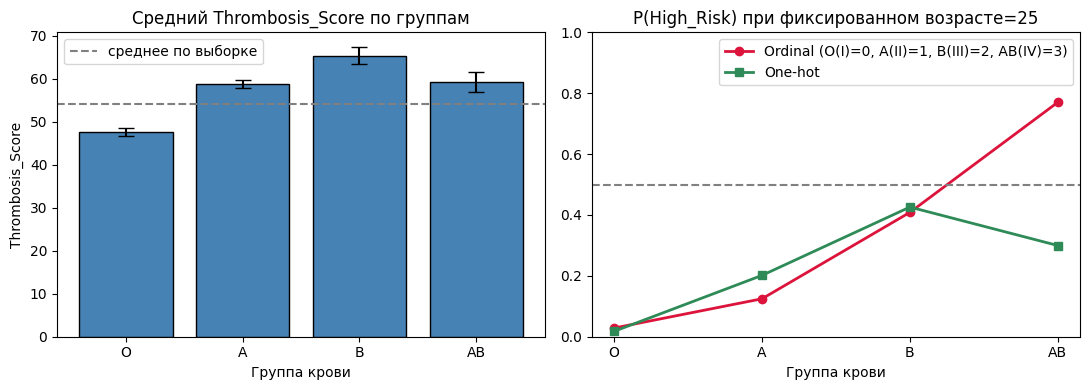

In [15]:
# @title
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- данные из вашего скрипта (без изменений) ---
np.random.seed(42); n = 300
blood = np.random.choice(['A','B','AB','O'], n, p=[0.40,0.10,0.05,0.45])
age   = np.random.randint(20, 80, n)

def thrombosis_score(bg, a):
    base=50; effect={'B':15,'O':-10,'A':2,'AB':5}[bg]
    return base + effect + max(0,(a-40)*0.5) + np.random.normal(0,8)

score  = np.array([thrombosis_score(b,a) for b,a in zip(blood,age)])
target = (score > np.median(score)).astype(int)
df = pd.DataFrame({'Blood_Group':blood,'Age':age,
                   'Thrombosis_Score':score,'High_Risk':target})

# ---------- 1. Ordinal ----------
df['bg_ord'] = df['Blood_Group'].map({'O':0, 'A':1, 'B':2, 'AB':3})
X_ord = df[['bg_ord','Age']].values
y     = df['High_Risk'].values
m_ord = LogisticRegression(max_iter=1000).fit(X_ord, y)

# ---------- 2. One-hot ----------
X_ohe_df = pd.get_dummies(df[['Blood_Group','Age']],
                          columns=['Blood_Group']).astype(float)
ohe_cols = X_ohe_df.columns.tolist()
m_ohe    = LogisticRegression(max_iter=1000).fit(X_ohe_df.values, y)

print("Ordinal coef для группы :", round(m_ord.coef_[0][0], 3))
print("Ordinal accuracy        :", round(accuracy_score(y, m_ord.predict(X_ord)), 3))
print("One-hot accuracy        :", round(accuracy_score(y, m_ohe.predict(X_ohe_df.values)), 3))
print("\nСредний Thrombosis_Score по группам:")
print(df.groupby('Blood_Group')['Thrombosis_Score'].mean().round(2).reindex(['O','A','B','AB']))

# ---------- Визуализация ----------
# порядок: O (I) = 0, A (II) = 1, B (III) = 2, AB (IV) = 3
groups = ['O','A','B','AB']
codes  = [0, 1, 2, 3]
age_fixed = 25

# предсказание Ordinal для фиксированного возраста
p_ord = m_ord.predict_proba([[c, age_fixed] for c in codes])[:, 1]

# предсказание One-hot для фиксированного возраста
rows = []
for g in groups:
    r = {'Age': age_fixed}
    for gg in groups:
        r[f'Blood_Group_{gg}'] = 1.0 if gg == g else 0.0
    rows.append(r)
p_ohe = m_ohe.predict_proba(pd.DataFrame(rows)[ohe_cols].values)[:, 1]

# средний Thrombosis_Score по группам (с планками ошибок)
means = df.groupby('Blood_Group')['Thrombosis_Score'].mean().reindex(groups)
sems  = df.groupby('Blood_Group')['Thrombosis_Score'].sem().reindex(groups)

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

# --- левый график: реальный уровень тромбозов ---
ax[0].bar(groups, means, yerr=sems, capsize=6,
          color='steelblue', edgecolor='black')
ax[0].axhline(df['Thrombosis_Score'].mean(), ls='--', c='gray',
              label='среднее по выборке')
ax[0].set_title('Средний Thrombosis_Score по группам')
ax[0].set_ylabel('Thrombosis_Score')
ax[0].set_xlabel('Группа крови')
ax[0].legend()

# --- правый график: что предсказывают модели ---
ax[1].plot(groups, p_ord, 'o-', lw=2, color='crimson',
           label='Ordinal (O(I)=0, A(II)=1, B(III)=2, AB(IV)=3)')
ax[1].plot(groups, p_ohe, 's-', lw=2, color='seagreen', label='One-hot')
ax[1].axhline(0.5, ls='--', c='gray')
ax[1].set_ylim(0, 1)
ax[1].set_title(f'P(High_Risk) при фиксированном возрасте={age_fixed}')
ax[1].set_xlabel('Группа крови')
ax[1].legend()

plt.tight_layout()
plt.show()

Мы закодировали группы крови числами: O=0, A=1, B=2, AB=3 (помните, что индексация всегда начинается с 0). Для человека это просто ярлыки. Для линейной модели — это уже числовая шкала

Модель логистической регрессии работает с числами линейно. Она видит эти цифры и думает: "Ага, это лестница! Чем выше число, тем выше риск". У неё есть только один коэффициент для этого столбца. Она физически не может выучить, что риск у B высокий, а у AB вдруг снова падает. Для неё 4 всегда больше 3. Для нее группа крови 4 всегда больше чем группа крови 3 по риску тромбоза лишь потому что 3 больше 4"

🔴 Красная линия (Ordinal): Модель насильно вытянула риск в линию от O к AB. Она совершила грубую медицинскую ошибку: занизила риск для B и завысила для AB, просто потому что мы заставили её видеть порядок там, где его нет.


🟢 Зеленая линия (One-Hot): Мы дали модели 4 независимых переключателя (бинарных столбца). Модель смогла выучить истинную, "зубчатую" форму зависимости: поднять риск для B, опустить для O и оставить средним для A и AB. Зеленая линия идеально повторяет синие столбцы реальных данных!"

#Аугментация
Как создать больше данных из ничего?

Искусственное увеличение объема и разнообразия обучающей выборки путем применения к имеющимся данным различных преобразований, сохраняющих смысл

Аугментация — это имитация естественной вариабельности, а не генерация фантазий.

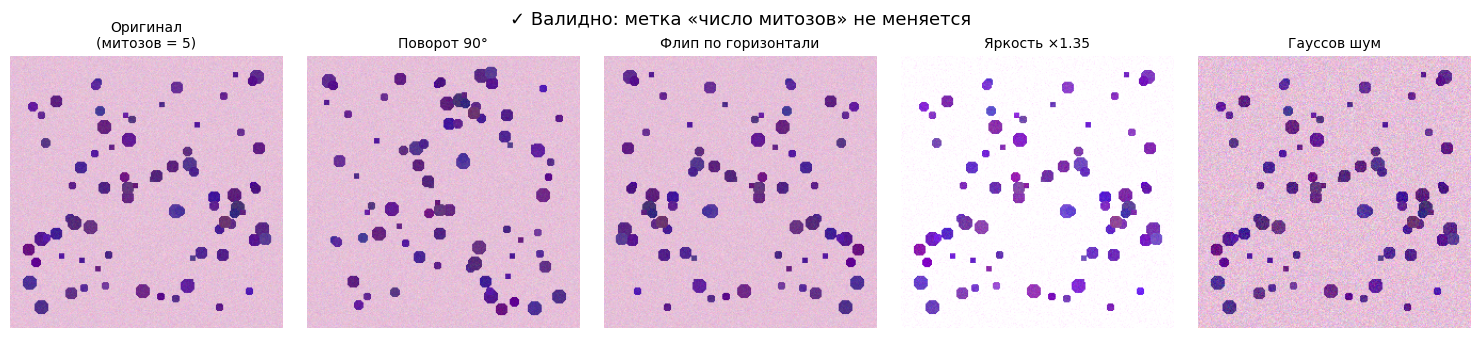

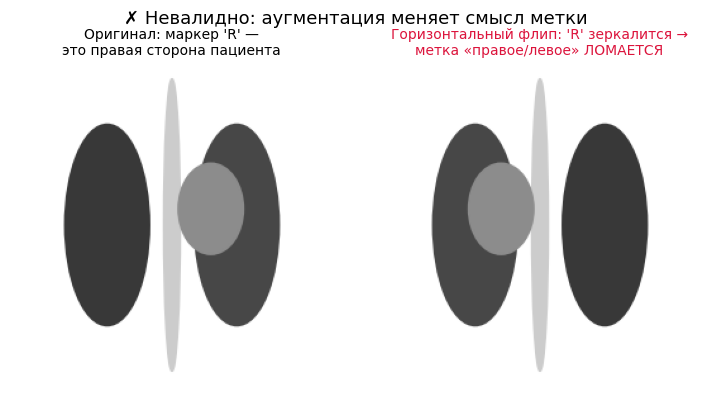

/tmp/ipykernel_2048/2395577184.py:106: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2048/2395577184.py:106: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


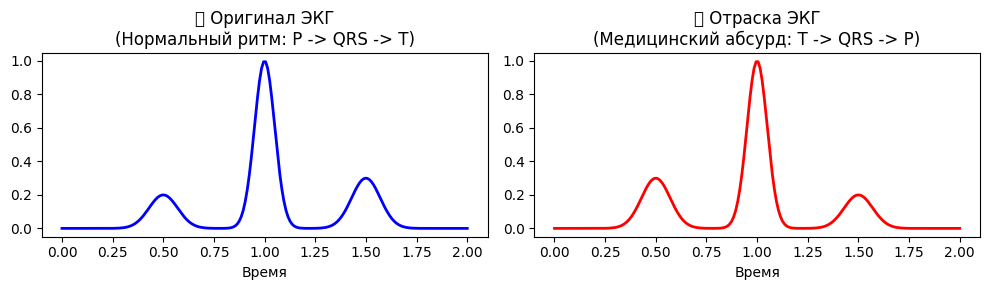

In [16]:
# @title
"""
Демонстрация аугментации: valid vs invalid.
pip install numpy matplotlib scipy
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.ndimage import rotate as ndrotate


# ---------- синтетические "медицинские" картинки ----------
def make_histology(size=256, seed=0):
    """Синтетический H&E-патч: розовый фон + фиолетовые ядра."""
    rng = np.random.default_rng(seed)
    y, x = np.mgrid[0:size, 0:size]
    img = np.empty((size, size, 3))
    img[..., 0], img[..., 1], img[..., 2] = 0.90, 0.75, 0.85
    for _ in range(80):
        cx, cy = rng.integers(15, size - 15, 2)
        r = rng.integers(3, 8)
        mask = (x - cx) ** 2 + (y - cy) ** 2 < r * r
        img[mask] = [0.35, 0.15, 0.55] + 0.05 * rng.standard_normal(3)
    img += 0.03 * rng.standard_normal(img.shape)
    return np.clip(img, 0, 1)


def make_chest_xray(size=256):
    """Синтетический рентген с маркером 'R' (как на реальных снимках)."""
    fig = plt.figure(figsize=(2, 2), dpi=size // 2)
    ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_facecolor("black"); ax.axis("off")
    ax.add_patch(Ellipse((0.30, 0.50), 0.26, 0.62, color="0.22"))  # лёгкое
    ax.add_patch(Ellipse((0.70, 0.50), 0.26, 0.62, color="0.28"))  # лёгкое
    ax.add_patch(Ellipse((0.50, 0.50), 0.05, 0.90, color="0.80"))  # позвоночник
    ax.add_patch(Ellipse((0.62, 0.55), 0.20, 0.28, color="0.55"))  # сердце
    ax.text(0.10, 0.82, "R", color="white", fontsize=36, fontweight="bold")
    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return img


# ---------- сами аугментации ----------
def rot(img, angle):
    axes = (0, 1) if img.ndim == 3 else None
    return ndrotate(img, angle, axes=axes, reshape=False, mode="reflect")

def flip_h(img):   return img[:, ::-1]
def brighten(img, k): return np.clip(img * k, 0, 1)
def noise(img, sigma=0.05, seed=0):
    rng = np.random.default_rng(seed)
    return np.clip(img + sigma * rng.standard_normal(img.shape), 0, 1)


# ============ ДЕМО 1: ВАЛИДНАЯ аугментация ============
hist = make_histology(256)

variants = [
    (hist,                  "Оригинал\n(митозов = 5)"),
    (rot(hist, 90),         "Поворот 90°"),
    (flip_h(hist),          "Флип по горизонтали"),
    (brighten(hist, 1.35),  "Яркость ×1.35"),
    (noise(hist, 0.05),     "Гауссов шум"),
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
for ax, (im, t) in zip(axes, variants):
    ax.imshow(np.clip(im, 0, 1)); ax.set_title(t, fontsize=10); ax.axis("off")
fig.suptitle("✓ Валидно: метка «число митозов» не меняется", fontsize=13)
plt.tight_layout(); plt.show()


# ============ ДЕМО 2: НЕВАЛИДНАЯ аугментация ============
xr = make_chest_xray(256)
xr_flip = flip_h(xr)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 4))
axes[0].imshow(xr)
axes[0].set_title("Оригинал: маркер 'R' —\nэто правая сторона пациента", fontsize=10)
axes[0].axis("off")
axes[1].imshow(xr_flip)
axes[1].set_title("Горизонтальный флип: 'R' зеркалится →\nметка «правое/левое» ЛОМАЕТСЯ", fontsize=10, color="crimson")
axes[1].axis("off")
fig.suptitle("✗ Невалидно: аугментация меняет смысл метки", fontsize=13)
plt.tight_layout(); plt.show()

# Создаем синтетический сигнал ЭКГ (кардиограмма)
t = np.linspace(0, 2, 200)
# Имитация зубца P, QRS, T
ecg_signal = np.exp(-((t-0.5)**2)/0.01) * 0.2 + \
             np.exp(-((t-1.0)**2)/0.005) * 1.0 + \
             np.exp(-((t-1.5)**2)/0.01) * 0.3

ecg_flipped = np.flip(ecg_signal) # Отражение по горизонтали!

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(t, ecg_signal, color='blue', lw=2)
axes[0].set_title('✅ Оригинал ЭКГ\n(Нормальный ритм: P -> QRS -> T)')
axes[0].set_xlabel('Время')

axes[1].plot(t, ecg_flipped, color='red', lw=2)
axes[1].set_title('❌ Отраска ЭКГ\n(Медицинский абсурд: T -> QRS -> P)')
axes[1].set_xlabel('Время')

plt.tight_layout()
plt.show()

🔴 1. Нельзя зеркалить (flip запрещён)
--------------------------------
ЭКГ

Отражение во времени = обратный ритм (T→QRS→P) — медицинский абсурд.
Отражение по амплитуде (инверсия) = «отрицательные зубцы» — уже другая патология.

--------------------------------
Рентген грудной клетки

Есть маркер «R/L».

Зеркалирование путает правое/левое. Плюс сердце физиологически слева — флип создаёт «синдром Kartagener» из здорового пациента.

--------------------------------
Маммография

Левая и правая грудь разные.

Зеркалирование левой превращает её в «правую», метка «сторона» ломается.


#Еще пример аугментации

Дали одну карточку: женщина, 34 года, 168 см, 62 кг, беременна.
Нужно сделать 100 похожих карточек.

Хороший врач чуть варьирует то, что и в жизни варьируется: рост ±1 см, вес ±0.5 кг, АД ±2. Пол и беременность оставляет как есть — их не «измеряют приблизительно».

Плохой врач прибавляет случайное число к каждой цифре подряд. Получаются беременные мужчины, люди ростом 250 см и весом 8 кг, возраст −5 лет.

#Формирование признаков (Feature engineering)

Алгоритмы машинного обучения могут быть математически 'глупы'. Они не знают, что такое биология. Наша задача — перевести биологический смысл на язык математики, создав новые признаки, которые делают скрытые закономерности очевидными

Модели может быть сложно найти нелинейную границу между ростом и весом. Но мы, зная биологию, можем свернуть два признака в один идеальный.

Пример: риск диабета зависит от ИМТ, а не от роста/веса по отдельности

/tmp/ipykernel_2048/4024611824.py:59: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2048/4024611824.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


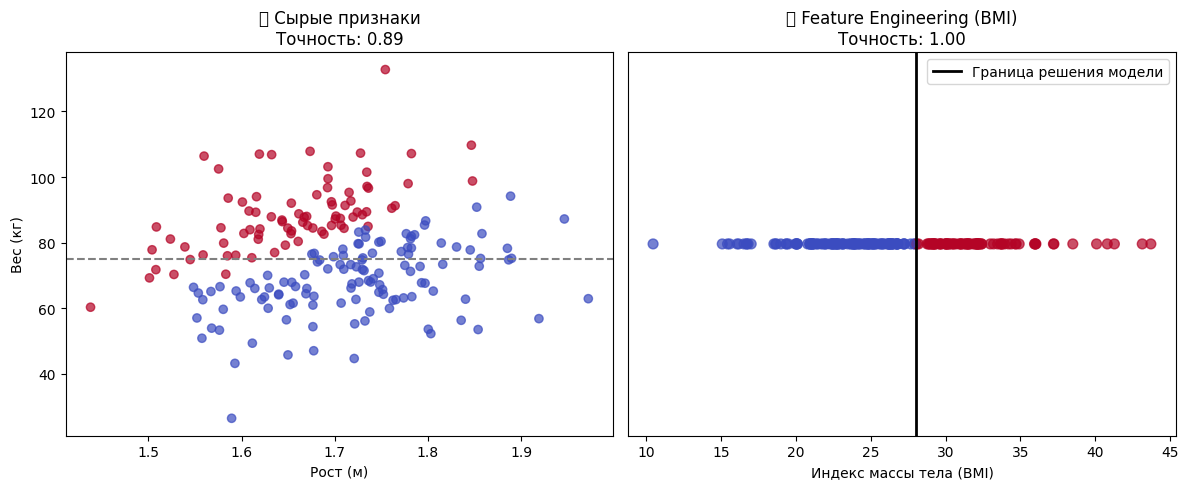

💡 Вывод: Точность выросла с 0.89 до 1.00 просто потому, что мы дали модели готовый биологический маркер.


In [17]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 200

# Генерируем "сырые" данные: Рост (м) и Вес (кг)
height = np.random.normal(1.70, 0.10, n)
weight = np.random.normal(75, 15, n)

# Истинная биологическая закономерность: риск диабета зависит от ИМТ, а не от роста/веса по отдельности
bmi_true = weight / (height ** 2)
# Добавляем шум, чтобы было реалистично
diabetes_risk = (bmi_true > 28).astype(int)

df = pd.DataFrame({'Height_m': height, 'Weight_kg': weight, 'Diabetes': diabetes_risk})

# ==========================================
# 1. ПОПЫТКА МОДЕЛИ НА СЫРЫХ ДАННЫХ
# ==========================================
X_raw = df[['Height_m', 'Weight_kg']].values
y = df['Diabetes'].values
model_raw = LogisticRegression().fit(X_raw, y)
acc_raw = accuracy_score(y, model_raw.predict(X_raw))

# ==========================================
# 2. FEATURE ENGINEERING: Создаем ИМТ
# ==========================================
df['BMI'] = df['Weight_kg'] / (df['Height_m'] ** 2)

X_eng = df[['BMI']].values
model_eng = LogisticRegression().fit(X_eng, y)
acc_eng = accuracy_score(y, model_eng.predict(X_eng))

# ==========================================
# 3. ВИЗУАЛИЗАЦИЯ
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Левый график: Сырые данные
scatter1 = axes[0].scatter(df['Height_m'], df['Weight_kg'], c=df['Diabetes'], cmap='coolwarm', alpha=0.7)
axes[0].set_title(f'❌ Сырые признаки\nТочность: {acc_raw:.2f}')
axes[0].set_xlabel('Рост (м)')
axes[0].set_ylabel('Вес (кг)')
axes[0].axhline(75, color='gray', ls='--') # Модель пытается провести прямые линии, но это не работает

# Правый график: Инжиниринг признаков
scatter2 = axes[1].scatter(df['BMI'], np.zeros_like(df['BMI']), c=df['Diabetes'], cmap='coolwarm', s=50, alpha=0.7)
axes[1].set_title(f'✅ Feature Engineering (BMI)\nТочность: {acc_eng:.2f}')
axes[1].set_xlabel('Индекс массы тела (BMI)')
axes[1].set_yticks([]) # Скрываем ось Y, так как это 1D признак
axes[1].axvline(28, color='black', ls='-', lw=2, label='Граница решения модели')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"💡 Вывод: Точность выросла с {acc_raw:.2f} до {acc_eng:.2f} просто потому, что мы дали модели готовый биологический маркер.")

Задача 5:

Вам доступны следующие сырые признаки:

Dose_mg — назначенная доза препарата (мг)

Weight_kg — масса тела пациента (кг)

Age_years — возраст пациента (лет)

eGFR — расчётная скорость клубочковой фильтрации (мл/мин/1.73м², показатель функции почек)

Предложите один новый признак, который, по вашему мнению, будет гораздо сильнее предсказывать токсическую реакцию, чем любая модель на сырых данных.

Объясните биологическую логику: почему именно этот признак, а не просто сырые данные, даст модели сигнал? Какую скрытую закономерность вы «обнажили»?

In [18]:
# @title
print('Dose_per_kg = Dose_mg / Weight_kg (доза на кг массы тела). Токсичность зависит не от абсолютной дозы, а от концентрации препарата в тканях')
print('Одна и та же доза 500 мг для человека 50 кг и 100 кг — это совершенно разные нагрузки.')
print('Деление сворачивает два признака в один, имеющий чёткий фармакологический смысл (мг/кг — стандартная единица в клинических рекомендациях)')

Dose_per_kg = Dose_mg / Weight_kg (доза на кг массы тела). Токсичность зависит не от абсолютной дозы, а от концентрации препарата в тканях
Одна и та же доза 500 мг для человека 50 кг и 100 кг — это совершенно разные нагрузки.
Деление сворачивает два признака в один, имеющий чёткий фармакологический смысл (мг/кг — стандартная единица в клинических рекомендациях)


#Обучающая и тестовая выборки (Train-test split)

Проблема:
Модель идеально работает на обучающих данных, но плохо на новых (переобучение)

Зачем это нужно?
Оценить способность модели обобщать знания на новых, ранее не виденных данных
Если оценивать модель на тех же данных, на которых она обучалась, мы измерим не качество прогноза, а способность к запоминанию

Как это делается:
Разбиваем данные на train/test (80/20, 70/30)
На train мы обучаем модель
На test мы только тестируем качество. Модель никогда не использует данные test для обучения


Представьте студента-медика, который готовится к госэкзамену.
У него есть сборник тестов за прошлые 5 лет (Обучающая выборка).
Если он просто зазубрит правильные ответы (1-А, 2-Б, 3-В), он получит 100% на этом сборнике. Но на реальном экзамене (Тестовая выборка), где вопросы сформулированы иначе, он провалится, потому что он выучил шум и формулировки, а не медицинские принципы.
В машинном обучении это называется переобучение (overfitting). Наша задача — научить модель принципам, а не зазубривать данные."

✅ Баланс классов: [20 20]
Train: 28 | Test: 12


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_2048/1908705138.py:67: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


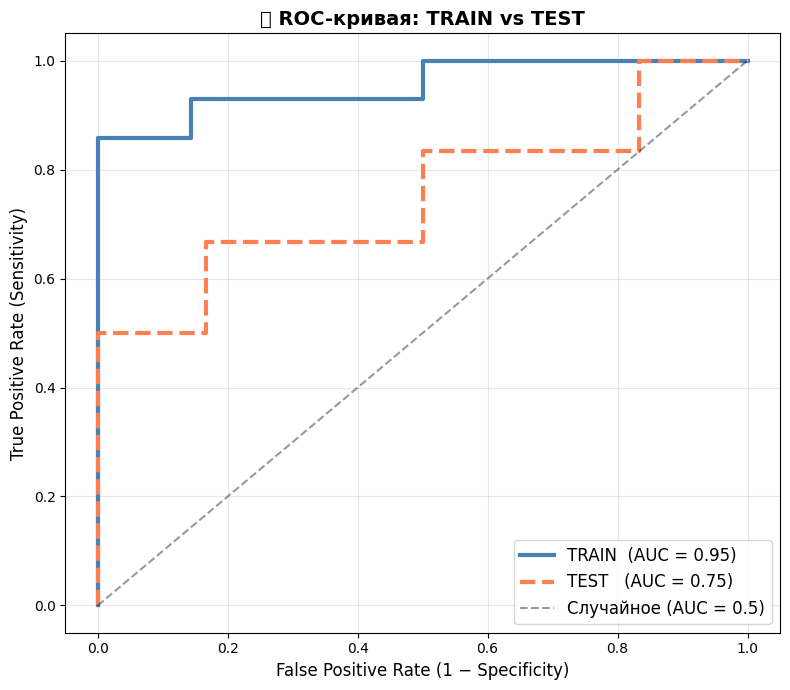

📊 РЕЗУЛЬТАТЫ
TRAIN:  AUC = 0.95
TEST:   AUC = 0.75
Разница (train − test) = +0.20


In [19]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# 1. ДАННЫЕ
np.random.seed(1)
n_samples = 40

age = np.linspace(20, 80, n_samples).reshape(-1, 1)
age_1d = age.ravel()

biomarker = 0.05 * age_1d + 0.0015 * (age_1d ** 2) + 4 * np.sin(age_1d / 4)
noise = np.random.normal(0, 15, n_samples)
biomarker_noisy = biomarker + noise

threshold = np.median(biomarker_noisy)
disease = (biomarker_noisy > threshold).astype(int)
print(f"✅ Баланс классов: {np.bincount(disease)}")

# 2. TRAIN / TEST
X_train, X_test, y_train, y_test = train_test_split(
    age, disease, test_size=0.30, random_state=1, stratify=disease
)
print(f"Train: {len(y_train)} | Test: {len(y_test)}")

# 3. МОДЕЛЬ
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

poly = PolynomialFeatures(degree=15, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s)
X_test_poly  = poly.transform(X_test_s)

model = LogisticRegression(C=1e8, max_iter=500_000, tol=1e-12, solver='lbfgs')
model.fit(X_train_poly, y_train)

# 4. МЕТРИКИ
p_train = model.predict_proba(X_train_poly)[:, 1]
p_test  = model.predict_proba(X_test_poly)[:, 1]

auc_train = roc_auc_score(y_train, p_train)
auc_test  = roc_auc_score(y_test,  p_test)

# 5. ГРАФИК
fig, ax = plt.subplots(figsize=(8, 7))

fpr_tr, tpr_tr, _ = roc_curve(y_train, p_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  p_test)

ax.plot(fpr_tr, tpr_tr, color='steelblue', lw=3,
        label=f'TRAIN  (AUC = {auc_train:.2f})')
ax.plot(fpr_te, tpr_te, color='coral', lw=3, ls='--',
        label=f'TEST   (AUC = {auc_test:.2f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Случайное (AUC = 0.5)')

ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('🎯 ROC-кривая: TRAIN vs TEST', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. ВЫВОД
print("=" * 55)
print("📊 РЕЗУЛЬТАТЫ")
print("=" * 55)
print(f"TRAIN:  AUC = {auc_train:.2f}")
print(f"TEST:   AUC = {auc_test:.2f}")
print(f"Разница (train − test) = {auc_train - auc_test:+.2f}")

# 🕵️‍♂️ Разведочный анализ данных (EDA) в биомедицине

**EDA (Exploratory Data Analysis)** — это процесс первичного исследования данных с помощью визуализаций и описательных статистик.

> 💡 **Цель:** Найти закономерности, аномалии, проверить гипотезы и предположения *до* построения сложных моделей машинного обучения.

### Почему это критически важно в биомедицине?
1. **Скрытые пропуски:** В медицинских данных пропуски часто кодируются как `0` или `-1` (например, уровень глюкозы = 0).
2. **Выбросы:** Ошибка измерения прибора или редкий клинический случай?
3. **Мультиколлинеарность:** В биомаркерах многие признаки сильно коррелируют (например, радиус, периметр и площадь опухоли), что может "сломать" линейные модели.
4. **Дисбаланс классов:** Здоровых пациентов в выборке часто значительно больше, чем больных.


## 🔍 ШАГ 1: Общий осмотр данных

**Что ищем:**
- Количество строк и столбцов
- Типы данных (числа, категории, текст)
- Явные пропуски (NaN)
- Базовые статистики (мин, макс, среднее, медиана)

**Почему это важно в биомедицине:**
- Несоответствие типов (например, возраст записан как текст "пятьдесят")
- Пропуски могут быть информативными (пациент не прошел тест)
- Экстремальные значения могут быть ошибками ввода (рост 2000 см)

📋 РАЗМЕРНОСТЬ ДАННЫХ
Количество пациентов (строк): 569
Количество признаков (столбцов): 31

📊 ИНФОРМАЦИЯ О ТИПАХ ДАННЫХ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter erro

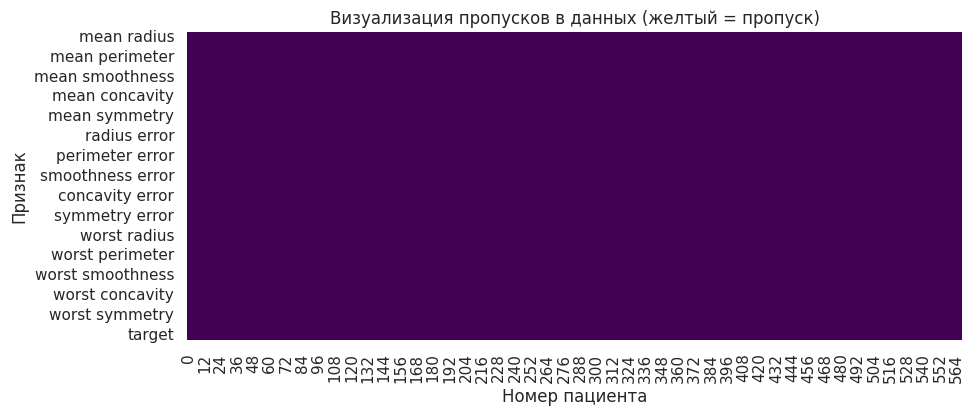

In [20]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Загрузка данных (Диагностика рака молочной железы)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # 0 = malignant (злокачественная), 1 = benign (доброкачественная)

# @title
# ШАГ 1: ОБЩИЙ ОСМОТР
print("="*60)
print("📋 РАЗМЕРНОСТЬ ДАННЫХ")
print("="*60)
print(f"Количество пациентов (строк): {df.shape[0]}")
print(f"Количество признаков (столбцов): {df.shape[1]}")

print("\n" + "="*60)
print("📊 ИНФОРМАЦИЯ О ТИПАХ ДАННЫХ")
print("="*60)
df.info()

print("\n" + "="*60)
print("🔢 ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ")
print("="*60)
df.describe().T  # Транспонируем для удобного чтения

print("\n" + "="*60)
print(" ПРОВЕРКА НА ЯВНЫЕ ПРОПУСКИ")
print("="*60)
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Пропусков': missing, 'Процент': missing_percent})
missing_df = missing_df[missing_df['Пропусков'] > 0]
if len(missing_df) == 0:
    print("✅ Явных пропусков (NaN) не обнаружено!")
else:
    display(missing_df.sort_values('Процент', ascending=False))

# Визуализация пропусков
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull().T, cmap='viridis', cbar=False)
plt.title('Визуализация пропусков в данных (желтый = пропуск)')
plt.xlabel('Номер пациента')
plt.ylabel('Признак')
plt.show()

## 🎯 ШАГ 2: Анализ целевой переменной

**Что проверяем:**
- Баланс классов (сколько больных vs здоровых)
- Распределение целевой переменной

**Почему это критично в биомедицине:**
- **Дисбаланс классов** — частая проблема: здоровых людей в выборке обычно больше
- Если 95% пациентов здоровы, модель может просто всегда предсказывать "здоров" и иметь accuracy 0.95


 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

Распределение классов:
target
1    357
0    212
Name: count, dtype: int64

Процентное соотношение:
Класс 1 (Доброкачественная (Benign)): 357 пациентов (62.7%)
Класс 0 (Злокачественная (Malignant)): 212 пациентов (37.3%)


/tmp/ipykernel_2048/4125975594.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, ax=axes[0], palette='Set2', edgecolor='black')
/tmp/ipykernel_2048/4125975594.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Malignant (0)\n(Злокачественная)', 'Benign (1)\n(Доброкачественная)'])


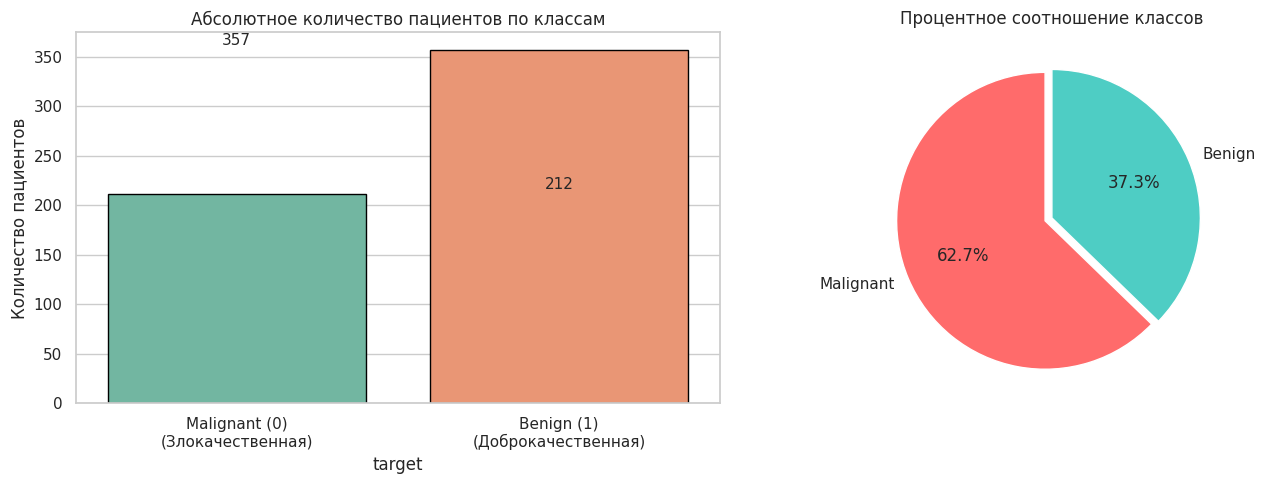


✅ ДАННЫЕ СБАЛАНСИРОВАНЫ
   Соотношение классов: 1.68:1


In [21]:
# @title
# ШАГ 2: ЦЕЛЕВАЯ ПЕРЕМЕННАЯ
print("="*60)
print(" АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*60)
print("\nРаспределение классов:")
print(df['target'].value_counts())

print("\nПроцентное соотношение:")
class_counts = df['target'].value_counts()
class_percent = df['target'].value_counts(normalize=True) * 100
for cls, cnt, pct in zip(class_counts.index, class_counts.values, class_percent.values):
    label = "Доброкачественная (Benign)" if cls == 1 else "Злокачественная (Malignant)"
    print(f"Класс {cls} ({label}): {cnt} пациентов ({pct:.1f}%)")

# Визуализация 1: Столбчатая диаграмма
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='target', data=df, ax=axes[0], palette='Set2', edgecolor='black')
axes[0].set_title('Абсолютное количество пациентов по классам', fontsize=12)
axes[0].set_xticklabels(['Malignant (0)\n(Злокачественная)', 'Benign (1)\n(Доброкачественная)'])
axes[0].set_ylabel('Количество пациентов')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Визуализация 2: Круговая диаграмма
colors = ['#FF6B6B', '#4ECDC4']
axes[1].pie(class_counts.values, labels=['Malignant', 'Benign'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0))
axes[1].set_title('Процентное соотношение классов', fontsize=12)

plt.tight_layout()
plt.show()

# Вывод о балансе
imbalance_ratio = class_counts[1] / class_counts[0]
print("\n" + "="*60)
if imbalance_ratio > 2 or imbalance_ratio < 0.5:
    print(f"⚠️  ДАННЫЕ ДИСБАЛАНСИРОВАНЫ!")
    print(f"   Соотношение классов: {imbalance_ratio:.2f}:1")
    print(f"   Рекомендуется: SMOTE, class_weight, или другие методы балансировки")
else:
    print(f"✅ ДАННЫЕ СБАЛАНСИРОВАНЫ")
    print(f"   Соотношение классов: {imbalance_ratio:.2f}:1")
print("="*60)

#📈 ШАГ 3: Распределения и выбросы
Зачем это нужно в биомедицине?

В медицинских данных выброс — это не всегда "мусор".
Это может быть:

Ошибка ввода/прибора: Возраст пациента 200 лет, уровень глюкозы 0 или 500 ммоль/л.

Редкий клинический случай:

Пациент с уникальной генетической мутацией или экстремальной реакцией на препарат.

-----------------------------------------------------------------

⚠️ Главное правило:

Слепое удаление всех выбросов может уничтожить самые ценные и интересные медицинские инсайты! Сначала смотрим, потом действуем.

/tmp/ipykernel_2048/1470669941.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, ax=axes[idx, 1], palette='Set2')
/tmp/ipykernel_2048/1470669941.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, ax=axes[idx, 1], palette='Set2')



📊 MEAN RADIUS:
   Среднее: 14.13 | Медиана: 13.37
   Границы нормы: [5.58 ; 21.90]
   🚨 Найдено выбросов: 14 шт. (2.5% от всех данных)

📊 MEAN AREA:
   Среднее: 654.89 | Медиана: 551.10
   Границы нормы: [-123.30 ; 1326.30]
   🚨 Найдено выбросов: 25 шт. (4.4% от всех данных)


/tmp/ipykernel_2048/1470669941.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, ax=axes[idx, 1], palette='Set2')



📊 WORST CONCAVE POINTS:
   Среднее: 0.11 | Медиана: 0.10
   Границы нормы: [-0.08 ; 0.31]
   🚨 Найдено выбросов: 0 шт. (0.0% от всех данных)


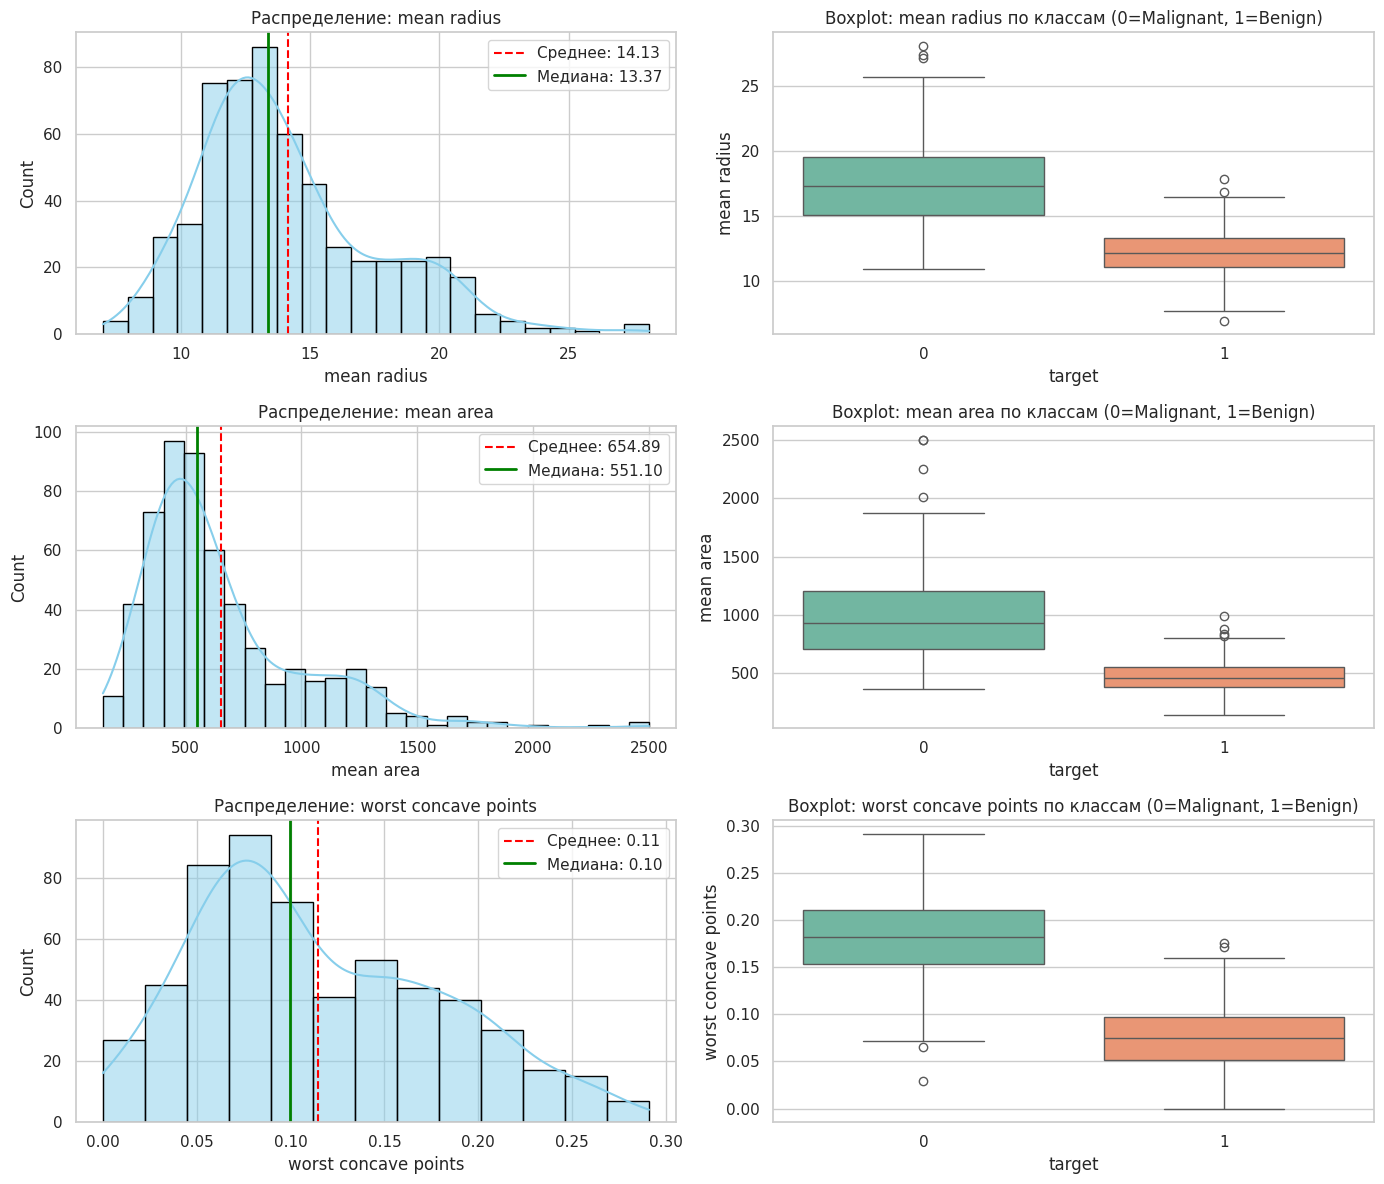

In [22]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Выбираем признаки для демонстрации (один из них часто имеет выбросы)
features_to_analyze = ['mean radius', 'mean area', 'worst concave points']

fig, axes = plt.subplots(len(features_to_analyze), 2, figsize=(14, 4 * len(features_to_analyze)))

for idx, feature in enumerate(features_to_analyze):
    # 1. Гистограмма + KDE
    sns.histplot(data=df, x=feature, kde=True, ax=axes[idx, 0], color='skyblue', edgecolor='black')
    mean_val = df[feature].mean()
    median_val = df[feature].median()

    axes[idx, 0].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.2f}')
    axes[idx, 0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Медиана: {median_val:.2f}')
    axes[idx, 0].set_title(f'Распределение: {feature}')
    axes[idx, 0].legend()

    # 2. Boxplot с разделением по классам (чтобы увидеть, не относятся ли выбросы к одному классу)
    sns.boxplot(x='target', y=feature, data=df, ax=axes[idx, 1], palette='Set2')
    axes[idx, 1].set_title(f'Boxplot: {feature} по классам (0=Malignant, 1=Benign)')

    # 3. Математический расчет выбросов методом IQR
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Находим строки, где значение выходит за границы
    outliers_mask = (df[feature] < lower_bound) | (df[feature] > upper_bound)
    outliers_count = outliers_mask.sum()

    print(f"\n📊 {feature.upper()}:")
    print(f"   Среднее: {mean_val:.2f} | Медиана: {median_val:.2f}")
    print(f"   Границы нормы: [{lower_bound:.2f} ; {upper_bound:.2f}]")
    print(f"   🚨 Найдено выбросов: {outliers_count} шт. ({outliers_count/len(df)*100:.1f}% от всех данных)")

plt.tight_layout()
plt.show()

#Гистограмма + KDE (Левая колонка)

Столбики: Показывают, сколько пациентов попало в определенный диапазон значений.
Линия (KDE): Сглаженная оценка плотности вероятности. Помогает увидеть общую форму.

Нормальное распределение ("Колокол"): Симметрично, среднее (mean) ≈ медиане (50%).

#Boxplot / "Ящик с усами" (Правая колонка)

Жирная линия внутри ящика: Медиана (50-й перцентиль). Половина пациентов имеет значение ниже этой линии, половина — выше.

Границы ящика: Нижний край = 25-й перцентиль (Q1), Верхний край = 75-й перцентиль (Q3). Внутри этого ящика находится 50% всех "типичных" пациентов.
Высота ящика (IQR): Межквартильный размах (Q3 - Q1). Показывает разброс средней половины данных.

"Усы" (линии от ящика): Границы "ожидаемых" значений. Обычно рассчитываются как Q1 - 1.5 * IQR и Q3 + 1.5 * IQR.

Отдельные точки за усами: Выбросы. Значения, статистически далекие от основной массы.

#ЧТО ДЕЛАТЬ С ВЫБРОСАМИ?

✅ Шаг 1: Domain Knowledge

Это физически возможное значение?

Если НЕТ (например, пульс 300, рост 2000 см): Это ошибка ввода.

👉 Решение: Заменить на NaN и импутировать медианой, или удалить строку целиком.

✅ Шаг 2: Трансформация данных (для скошенных распределений)

Если "хвост" тянется вправо (много умеренных значений и несколько гигантских), модель может быть нестабильной. Логарифмирование "сжимает" шкалу, делая распределение более похожим на нормальное.

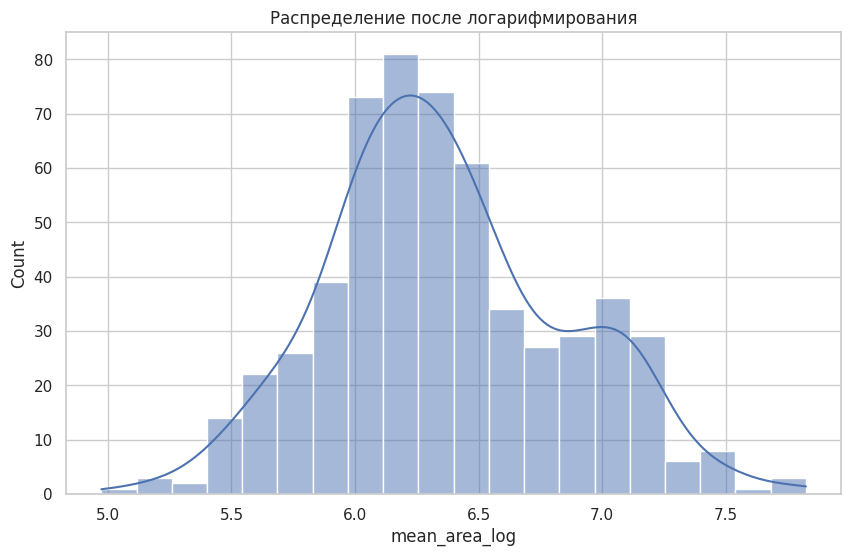

In [23]:
# np.log1p безопасен, так как считает log(1 + x), что работает даже если x = 0
df['mean_area_log'] = np.log1p(df['mean area'])

sns.histplot(df['mean_area_log'], kde=True)
plt.title('Распределение после логарифмирования')
plt.show()

## Задача 5

**Контекст:** Вы — data scientist в отделении интенсивной терапии (ICU). Главный врач дал вам базу данных о 800 пациентах и попросил очистить её перед построением модели прогнозирования смертности.

**Признаки:**
- **Возраст** (годы)
- **T** — температура тела (°C)
- **ЧСС** — частота сердечных сокращений (уд/мин)
- **SpO₂** — сатурация кислорода (%)
- **Лактат** — уровень лактата в крови (ммоль/л) — маркер тканевой гипоксии
- **АД сист.** — систолическое артериальное давление (мм рт. ст.)
- **Дни** — длительность госпитализации (дни)

**Ваша задача:** Перед вами 8 подозрительных строк. Для каждой решите:
- ❌ **УДАЛИТЬ** — это ошибка ввода/прибора
- ⚠️ **ОСТАВИТЬ** — это редкий, но реальный клинический случай
- 🔍 **ПРОВЕРИТЬ** — нужно уточнить у медицинского персонала

---

### 📊 ТАБЛИЦА ДЛЯ АНАЛИЗА

| № | Возраст | T (°C) | ЧСС | SpO₂ (%) | Лактат | АД сист. | Дни | Ваш вердикт |
|---|---------|--------|-----|----------|--------|----------|-----|-------------|
| 1 | 67 | −12 | 88 | 96 | 1.2 | 130 | 5 | ? |
| 2 | 54 | 36.6 | 0 | 98 | 1.0 | 125 | 3 | ? |
| 3 | 72 | 38.9 | 118 | 94 | 18.5 | 85 | 2 | ? |
| 4 | 45 | 37.0 | 76 | 150 | 1.1 | 120 | 4 | ? |
| 5 | 81 | 36.2 | 92 | 91 | 2.4 | 0 | 7 | ? |
| 6 | 29 | 39.5 | 140 | 97 | 3.1 | 110 | −2 | ? |
| 7 | 58 | 34.1 | 320 | 95 | 4.0 | 100 | 6 | ? |
| 8 | 63 | 36.8 | 84 | 96 | 1.3 | 128 | 120 | ? |

---


## ⚖️ ШАГ 4: Масштабирование признаков (Feature Scaling)

**Почему это критически важно?**
Алгоритмы машинного обучения (особенно основанные на расстояниях, как KNN или SVM, и на градиентах, как нейросети или линейная регрессия) **не понимают смысл данных, они видят только числа**.

🧠 **Как "думает" алгоритм:**
Представьте два признака:
1. `Возраст`: от 20 до 80 лет (разброс ~60)
2. `Экспрессия гена`: от 500 до 15 000 (разброс ~14 500)

Если экспрессия изменится на 100 единиц, алгоритм посчитает это "гигантским" изменением. А если возраст изменится на 10 лет (что для человека очень много!), алгоритм посчитает это "мелочью", потому что число 10 намного меньше 100. **Признак с большими числами будет необоснованно доминировать в модели.**

**Решение:** Привести все признаки к единому, справедливому масштабу.

### 📖 ДВА ГЛАВНЫХ СПОСОБА МАСШТАБИРОВАНИЯ

---

#### 1. Нормализация (Min-Max Scaling) — "Метод процентов"

🏫 **Аналогия: Рост учеников в классе**

Представьте, что вы хотите сравнить рост 30 школьников, но не в сантиметрах, а в **"процентах от самого высокого"**.

- Самый низкий ученик (150 см) получает **0%**
- Самый высокий ученик (180 см) получает **100%**
- Все остальные "растягиваются" между ними.

Теперь представьте, что рост 165 см → это 50%. Рост 170 см → это 67%. Всё понятно, все видно.

⚠️ **НО! Что если в класс зайдет баскетболист ростом 220 см?**

Теперь:
- Баскетболист (220 см) = **100%**
- Самый высокий обычный ученик (180 см) = **43%**
- Все остальные сжались в диапазон **0% – 43%**

Разница между 150 см и 180 см, которая раньше была видна, теперь **почти незаметна** — все обычные ученики "сплющились" в нижнюю часть шкалы. Модель перестает видеть разницу между ними!

🔢 **На числах (до и после):**

| Пациент | Исходный рост | MinMax (без выброса) | MinMax (с выбросом 220 см) |
|---------|---------------|----------------------|----------------------------|
| А       | 150 см        | 0.00                 | 0.00                       |
| Б       | 165 см        | 0.50                 | 0.21 ← разница исчезла!    |
| В       | 180 см        | 1.00                 | 0.43 ← был лидером, стал середнячком |
| Г (выброс)| 220 см       | —                    | 1.00                       |

📐 **Формула (для справки):** `X_new = (X - min) / (max - min)`

🎯 **Вывод:** Min-Max отлично работает, когда **нет выбросов**. Но один экстремальный пациент может "сломать" всю шкалу.

---

#### 2. Стандартизация (Standard Scaler) — "Метод отклонений от среднего" 🏆

🏥 **Аналогия: Температура "относительно нормы"**

Представьте, что вы врач. Вам не важно, что на улице +25°C. Вам важно: **"насколько сегодня теплее или холоднее, чем обычно в этом месяце?"**

- Если средняя температура месяца +20°C, а сегодня +25°C → это **"+5 градусов от нормы"**
- Если завтра +15°C → это **"-5 градусов от нормы"**
- Если послезавтра +20°C → это **"ровно норма" (0)**

Теперь даже если завтра будет аномальная жара +40°C, это просто станет **"+20 от нормы"**. Все остальные дни останутся на своих местах, их "относительная температура" не изменится!

🔢 **На числах (до и после):**

| Пациент | Исходный рост | Standard (без выброса) | Standard (с выбросом 220 см) |
|---------|---------------|------------------------|------------------------------|
| А       | 150 см        | -1.2                   | -1.0 ← почти не изменилось  |
| Б       | 165 см        | 0.0 (среднее)          | -0.2 ← почти не изменилось  |
| В       | 180 см        | +1.2                   | +0.6 ← почти не изменилось  |
| Г (выброс)| 220 см       | —                      | +4.5 ← честно показывает отклонение |

Видите? Даже когда появился баскетболист, **отношения между обычными учениками сохранились**. Модель по-прежнему видит разницу между ними!

📐 **Формула (для справки):** `X_new = (X - mean) / std`

> 💡 **Как это прочитать?** Значение **+2** означает: "Этот пациент на 2 стандартных отклонения выше среднего". Значение **-1.5** означает: "На 1.5 стандартных отклонения ниже среднего".

🎯 **Вывод:** Standard Scaler — **золотой стандарт в биомедицине**, потому что медицинские данные часто содержат выбросы (редкие заболевания, ошибки приборов), и нам нужно, чтобы они не ломали всю картину.

---




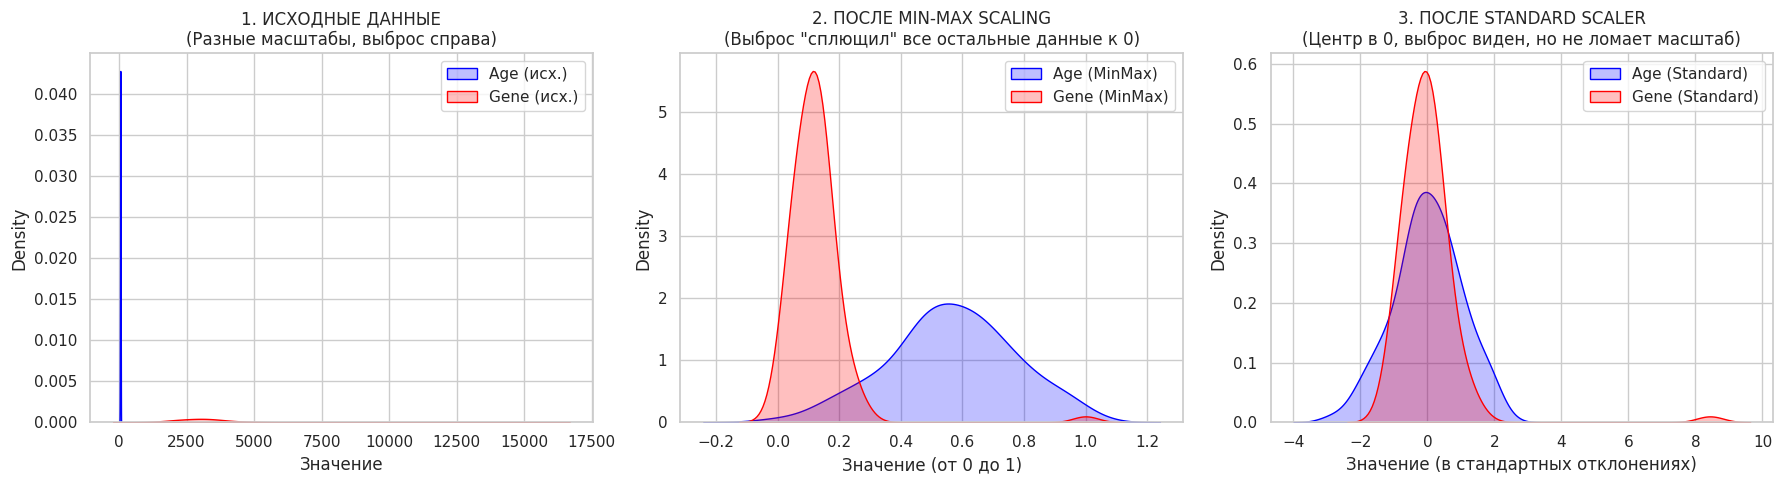

🔢 КАК ИЗМЕНИЛИСЬ КОНКРЕТНЫЕ ЧИСЛА:
        Age  Gene_Expression  Age_Standard  Gene_Standard  Age_MinMax  \
0    54.967         1867.703         0.660         -0.902       0.697   
1    48.617         2663.484        -0.045         -0.336       0.555   
2    56.477         2725.828         0.827         -0.292       0.731   
100  55.000        15000.000         0.663          8.435       0.698   

     Gene_MinMax  
0          0.030  
1          0.089  
2          0.093  
100        1.000  

💡 ОБРАТИТЕ ВНИМАНИЕ НА ПОСЛДНЮЮ СТРОКУ (ВЫБРОС):
Исходный ген: 15000
После MinMax: 1.000 (стал 1.0, а все остальные сжались в 0.00x)
После Standard: 8.435 (стал ~3.5, что честно показывает его отклонение)


In [24]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

# 1. Создаем искусственные данные с РАЗНЫМ масштабом и ВЫБРОСОМ
np.random.seed(42)
# Возраст: нормальное распределение вокруг 50 лет, разброс небольшой
age = np.random.normal(loc=50, scale=10, size=100)
# Экспрессия гена: значения от 1000 до 5000
gene_expr = np.random.normal(loc=3000, scale=800, size=100)

# ДОБАВЛЯЕМ ВЫБРОС: один пациент с аномально высокой экспрессией гена
gene_expr = np.append(gene_expr, [15000])
age = np.append(age, [55]) # Добавляем соответствующий возраст

df_scale = pd.DataFrame({'Age': age, 'Gene_Expression': gene_expr})

# ==========================================
# 2. ПРИМЕНЯЕМ МАСШТАБИРОВАНИЕ
# ==========================================

# Нормализация (Min-Max)
minmax_scaler = MinMaxScaler()
df_scale['Gene_MinMax'] = minmax_scaler.fit_transform(df_scale[['Gene_Expression']])
df_scale['Age_MinMax'] = minmax_scaler.fit_transform(df_scale[['Age']])

# Стандартизация (Standard)
std_scaler = StandardScaler()
df_scale['Gene_Standard'] = std_scaler.fit_transform(df_scale[['Gene_Expression']])
df_scale['Age_Standard'] = std_scaler.fit_transform(df_scale[['Age']])

# ==========================================
# 3. ВИЗУАЛИЗАЦИЯ: СРАВНЕНИЕ ДО И ПОСЛЕ
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: ИСХОДНЫЕ ДАННЫЕ
sns.kdeplot(data=df_scale, x='Age', fill=True, color='blue', label='Age (исх.)', ax=axes[0])
sns.kdeplot(data=df_scale, x='Gene_Expression', fill=True, color='red', label='Gene (исх.)', ax=axes[0])
axes[0].set_title('1. ИСХОДНЫЕ ДАННЫЕ\n(Разные масштабы, выброс справа)')
axes[0].set_xlabel('Значение')
axes[0].legend()

# График 2: ПОСЛЕ MIN-MAX (НОРМАЛИЗАЦИЯ)
sns.kdeplot(data=df_scale, x='Age_MinMax', fill=True, color='blue', label='Age (MinMax)', ax=axes[1])
sns.kdeplot(data=df_scale, x='Gene_MinMax', fill=True, color='red', label='Gene (MinMax)', ax=axes[1])
axes[1].set_title('2. ПОСЛЕ MIN-MAX SCALING\n(Выброс "сплющил" все остальные данные к 0)')
axes[1].set_xlabel('Значение (от 0 до 1)')
axes[1].legend()

# График 3: ПОСЛЕ STANDARD SCALER (СТАНДАРТИЗАЦИЯ)
sns.kdeplot(data=df_scale, x='Age_Standard', fill=True, color='blue', label='Age (Standard)', ax=axes[2])
sns.kdeplot(data=df_scale, x='Gene_Standard', fill=True, color='red', label='Gene (Standard)', ax=axes[2])
axes[2].set_title('3. ПОСЛЕ STANDARD SCALER\n(Центр в 0, выброс виден, но не ломает масштаб)')
axes[2].set_xlabel('Значение (в стандартных отклонениях)')
axes[2].legend()

plt.tight_layout()
plt.show()

# ==========================================
# 4. ПОСМОТРИМ НА ЦИФРЫ (для первых 5 строк и последней с выбросом)
# ==========================================
print("="*80)
print("🔢 КАК ИЗМЕНИЛИСЬ КОНКРЕТНЫЕ ЧИСЛА:")
print("="*80)
# Берем первые 3 обычных пациента и 1 последнего (выброс)
demo_idx = [0, 1, 2, 100]
display_cols = ['Age', 'Gene_Expression', 'Age_Standard', 'Gene_Standard', 'Age_MinMax', 'Gene_MinMax']
print(df_scale.loc[demo_idx, display_cols].round(3))

print("\n💡 ОБРАТИТЕ ВНИМАНИЕ НА ПОСЛДНЮЮ СТРОКУ (ВЫБРОС):")
print(f"Исходный ген: {df_scale.loc[100, 'Gene_Expression']:.0f}")
print(f"После MinMax: {df_scale.loc[100, 'Gene_MinMax']:.3f} (стал 1.0, а все остальные сжались в 0.00x)")
print(f"После Standard: {df_scale.loc[100, 'Gene_Standard']:.3f} (стал ~3.5, что честно показывает его отклонение)")

## 🗑️ ШАГ 5: Мусорные данные (Garbage Features)

Избавление от лишних признаков критически важно для предотвращения переобучения (overfitting).

**Что смело удаляем:**
1. **Идентификаторы:** `Patient_ID`, `Name`, `Дата_рождения` (в сыром виде). Они не помогают предсказать диагноз, но модель может случайно «запомнить» конкретные ID (утечка данных).
2. **Признаки с огромным числом пропусков:** Если столбец пуст на 80-90%, его заполнение будет чистым шумом.
3. **Константы:** Признаки, где у всех пациентов одно и то же значение (например, `Страна: 'Россия'` для 100% выборки).

In [25]:
# @title
# ДЕМОНСТРАЦИЯ: Очистка от мусорных признаков
df_garbage = pd.DataFrame({
    'Patient_ID': [101, 102, 103, 104, 105], # Мусор 1: Идентификатор
    'Hospital_City': ['Moscow', 'Moscow', 'Moscow', 'Moscow', 'Moscow'], # Мусор 2: Константа
    'Rare_Gene_Test': [np.nan, np.nan, 5.4, np.nan, np.nan], # Мусор 3: 80% пропусков
    'Age': [45, 50, 62, 30, 55], # Полезный признак
    'Diagnosis': [0, 1, 1, 0, 1] # Целевая переменная
})

print("Исходный 'замусоренный' датасет:")
display(df_garbage)

# 1. Удаляем ID
df_clean = df_garbage.drop(columns=['Patient_ID'])

# 2. Удаляем константы (где количество уникальных значений == 1)
nunique = df_clean.nunique()
cols_to_drop = nunique[nunique == 1].index
df_clean = df_clean.drop(columns=cols_to_drop)

# 3. Удаляем столбцы, где пропусков больше 50%
threshold = 0.5
missing_ratio = df_clean.isnull().mean()
cols_with_too_many_nans = missing_ratio[missing_ratio > threshold].index
df_clean = df_clean.drop(columns=cols_with_too_many_nans)

print("\nОчищенный датасет (готов к ML):")
display(df_clean)

Исходный 'замусоренный' датасет:


,Patient_ID,Hospital_City,Rare_Gene_Test,Age,Diagnosis
0,101,Moscow,NaN,45,0
1,102,Moscow,NaN,50,1
2,103,Moscow,5.4,62,1
3,104,Moscow,NaN,30,0
4,105,Moscow,NaN,55,1



Очищенный датасет (готов к ML):


,Age,Diagnosis
0,45,0
1,50,1
2,62,1
3,30,0
4,55,1


## ☣️ ШАГ 6: Смещенные данные (Biased Data)

Самая коварная проблема. Данные могут быть чистыми, без пропусков и выбросов, но **систематически искажать реальность**.

### 🏥 Кейс: IBM Watson for Oncology
Эта система ИИ должна была рекомендовать персонализированное лечение рака кожи. Однако проект столкнулся с серьезными проблемами и был в итоге свернут.

**В чем была причина?**
Как выяснилось, система обучалась не на обширном наборе реальных историй болезни из разных стран, а на небольшом количестве **«синтетических» (искусственных) случаев**, придуманных экспертами *одного конкретного клинического центра в одной конкретной стране*.

**Последствия:**
- Watson впитал точку зрения узкой группы врачей, а не богатую медицинскую реальность.
- Рекомендации ИИ иногда были не просто неточными, а **опасными**: он предлагал схемы лечения, которые реальному пациенту могли бы навредить.
- Внутренний аудит выявил «несколько примеров небезопасных и неправильных рекомендаций».


Что могло случиться?






"Идеальный" стартап

EDA датасета для обучения модели (50000 изображений).
**Отчет EDA выглядел безупречно:**
- ✅ Пропусков (NaN): 0%
- ✅ Выбросов: 0% (все изображения высокого разрешения, корректного размера)
- ✅ Баланс классов: 50% "Доброкачественная", 50% "Меланома"
- ✅ Точность (Accuracy) на валидационной выборке: **98.5%**

Инвесторы в восторге и готовы запускать приложение в массовую продажу по всему миру.


/tmp/ipykernel_2048/3639033963.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Skin_Type', data=df_meta, order=df_meta['Skin_Type'].value_counts().index, palette='mako')
/tmp/ipykernel_2048/3639033963.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model_Accuracy', y='Skin_Type', data=df_meta, order=df_meta['Skin_Type'].value_counts().index, palette='mako')


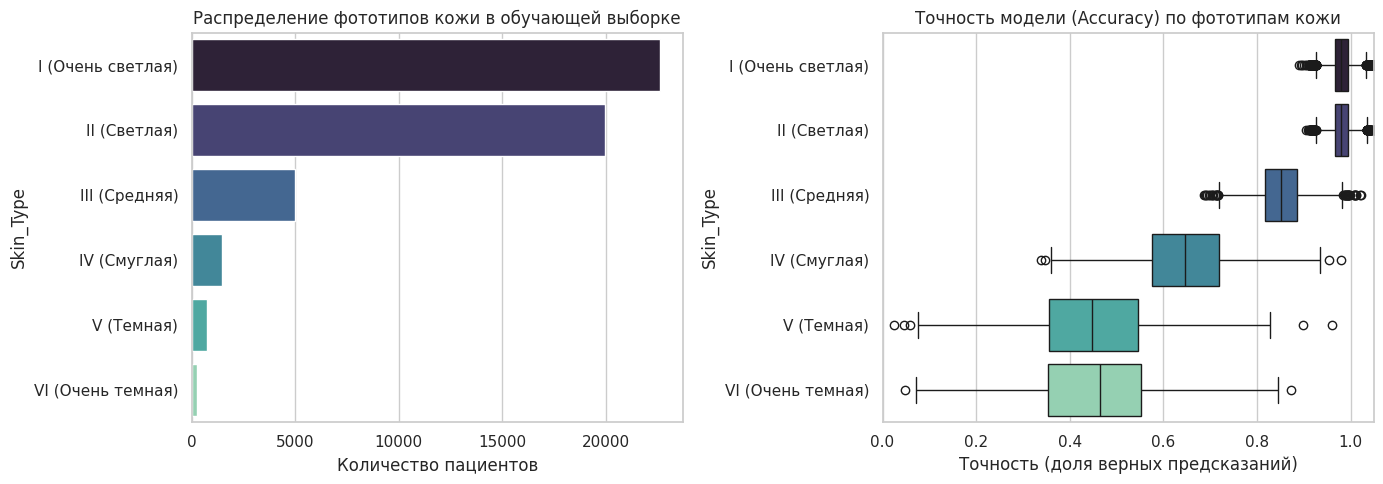

📊 Сводная статистика по фототипам:


,Средняя точность
Skin_Type,
I (Очень светлая),0.98
II (Светлая),0.98
III (Средняя),0.85
IV (Смуглая),0.65
V (Темная),0.45
VI (Очень темная),0.45


In [26]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Генерируем "секретные" метаданные для 50 000 пациентов
np.random.seed(42)
n = 50000

# Фототип кожи по шкале Фитцпатрика (I-VI)
# I-II: Очень светлая кожа, VI: Очень темная кожа
# Стартап собирал данные в основном в одной клинике в Северной Европе
skin_types = np.random.choice(['I (Очень светлая)', 'II (Светлая)', 'III (Средняя)',
                               'IV (Смуглая)', 'V (Темная)', 'VI (Очень темная)'],
                              size=n, p=[0.45, 0.40, 0.10, 0.03, 0.015, 0.005])

# Имитация точности модели для разных фототипов (реальная проблема таких ИИ)
# Для светлой кожи точность высокая, для темной - катастрофически низкая (ложноотрицательные результаты)
def get_accuracy(skin_type):
    if skin_type in ['I (Очень светлая)', 'II (Светлая)']: return np.random.normal(0.98, 0.02)
    elif skin_type == 'III (Средняя)': return np.random.normal(0.85, 0.05)
    elif skin_type == 'IV (Смуглая)': return np.random.normal(0.65, 0.10)
    else: return np.random.normal(0.45, 0.15) # Для V и VI

accuracies = [get_accuracy(st) for st in skin_types]

df_meta = pd.DataFrame({'Skin_Type': skin_types, 'Model_Accuracy': accuracies})

# ВИЗУАЛИЗАЦИЯ 1: Распределение данных
plt.subplot(1, 2, 1)
sns.countplot(y='Skin_Type', data=df_meta, order=df_meta['Skin_Type'].value_counts().index, palette='mako')
plt.title('Распределение фототипов кожи в обучающей выборке', fontsize=12)
plt.xlabel('Количество пациентов')

# ВИЗУАЛИЗАЦИЯ 2: Точность модели по фототипам
plt.subplot(1, 2, 2)
sns.boxplot(x='Model_Accuracy', y='Skin_Type', data=df_meta, order=df_meta['Skin_Type'].value_counts().index, palette='mako')
plt.title('Точность модели (Accuracy) по фототипам кожи', fontsize=12)
plt.xlabel('Точность (доля верных предсказаний)')
plt.xlim(0, 1.05)

plt.tight_layout()
plt.show()

print("📊 Сводная статистика по фототипам:")
display(df_meta.groupby('Skin_Type')['Model_Accuracy'].mean().round(2).to_frame('Средняя точность'))

Именно это произошло с IBM Watson. Он обучался на "идеальных" синтетических случаях от врачей одного госпиталя в США. Когда его применили в Индии или для пациентов с сопутствующими заболеваниями, которых не было в "идеальной" обучающей выборке, он начал давать опасные рекомендации.

> 💡 **Главный урок:** *Garbage In, Garbage Out (Мусор на входе — мусор на выходе).*
> Самый совершенный алгоритм машинного обучения не спасет, если данные нерепрезентативны, неэтично собраны или не отражают реальное разнообразие пациентов.